## Minería de flujos - Análisis

Se analizan los resultados obtenidos en DGIM, Bloom Filter y Count-Min Sketch

### Imports

In [1]:
import os, socket
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": .3})
pd.set_option("display.max_colwidth", 80)

### Utilidades

- Constantes

In [2]:
proyecto = Path.cwd()
while not (proyecto / "docker-compose.yml").exists() and proyecto != proyecto.parent:
    proyecto = proyecto.parent
flujos_dir = proyecto / "04_Flujos" / "temp"
out_dir = proyecto / "04_Flujos" / "temp" / "d_analisis"
fig_dir, tab_dir, web_dir = out_dir / "figs", out_dir / "tablas", out_dir / "web"
for d in (fig_dir, tab_dir, web_dir):
    d.mkdir(parents=True, exist_ok=True)

- Figuras y tablas

In [3]:
def mostrar_fig(nombre):
    plt.tight_layout()
    plt.savefig(fig_dir / f"{nombre}.png", dpi=150, bbox_inches="tight")
    plt.show()

def guardar_tabla(df, nombre):
    sdf = spark.createDataFrame(df) if isinstance(df, pd.DataFrame) else df
    sdf.coalesce(1).write.mode("overwrite").parquet(str(tab_dir / nombre))
    sdf.toPandas().to_json(web_dir / f"{nombre}.json", orient="records", force_ascii=False, date_format="iso", indent=1)
    return len(df) if isinstance(df, pd.DataFrame) else sdf.count()

- Spark

In [4]:
spark_master = os.environ.get("spark_master", "local[*]")

builder = (SparkSession.builder
           .appName("flujos-analisis")
           .master(spark_master)
           .config("spark.driver.memory",   os.environ.get("SPARK_DRIVER_MEMORY", "2g"))
           .config("spark.executor.memory", os.environ.get("SPARK_EXECUTOR_MEMORY", "2g"))
           .config("spark.sql.shuffle.partitions", "24")
           .config("spark.ui.showConsoleProgress", "false")
           .config("spark.sql.session.timeZone", "America/Lima"))

if spark_master.startswith("spark://"):
    builder = (builder.config("spark.driver.host", socket.gethostname())
                      .config("spark.driver.bindAddress", "0.0.0.0"))

spark = builder.getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

26/10/08 22:00:43 WARN Utils: Your hostname, Paolos-MacBook-Pro.local resolves to a loopback address: 127.0.0.1; using 192.168.1.38 instead (on interface en0)
26/10/08 22:00:43 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/10/08 22:00:44 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


### Verificación del cluster

In [5]:
sc = spark.sparkContext
estado = sc._jsc.sc().getExecutorMemoryStatus()

print(f"Master        : {sc.master}")
print(f"Executors     : {estado.size() - 1}")
print(f"Cores totales : {sc.defaultParallelism}")
print(f"Memoria driver: {sc._jvm.java.lang.Runtime.getRuntime().maxMemory() / 1024**3:.1f} GB")
print("UI del job    : http://localhost:4040")

Master        : local[*]
Executors     : 0
Cores totales : 8
Memoria driver: 2.0 GB
UI del job    : http://localhost:4040


---
### 1. Carga de resultados

In [6]:
def leer(nb, tabla):
    ruta = flujos_dir / nb / "tablas" / tabla
    assert ruta.exists(), f"Corre {nb}.ipynb (Run All) antes que este notebook."
    return spark.read.parquet(str(ruta)).toPandas()

resumen = pd.concat([leer(nb, "resumen") for nb in ["a_dgim", "b_bloom", "c_sketch"]], ignore_index=True)
serie = leer("a_dgim", "serie")
reincidencia_mes = leer("b_bloom", "reincidencia_mes")
postor_reincidencia = leer("b_bloom", "postor_reincidencia")
heavy_hitters = leer("c_sketch", "heavy_hitters")
print(f"Estructuras: {', '.join(resumen['estructura'])}")

Estructuras: DGIM, Bloom Filter, Count-Min Sketch


### 2. Precisión

In [7]:
resumen[["estructura", "tarea", "parametros", "metrica_error", "error"]]

,estructura,tarea,parametros,metrica_error,error
0,DGIM,postor único en ventana,"N=6600, r=2",error relativo medio,0.108862
1,Bloom Filter,reincidencia entidad-proveedor,"m=1187311, k=7",tasa de falsos positivos (final),0.010240
2,Count-Min Sketch,frecuencia de pares entidad-proveedor,"w=33390, d=5",sobreestimación media (apariciones),1.981206


- Las 3 cumplen su garantía teórica: DGIM 10.9% < 50%, Bloom 1.02% ≈ 1% objetivo, Count-Min Sketch apariciones < 15

- Tipo de error distinto en cada una: DGIM sub o sobreestima; Bloom solo da falsos positivos; Count-Min solo sobreestima

### 3. Memoria y tiempo

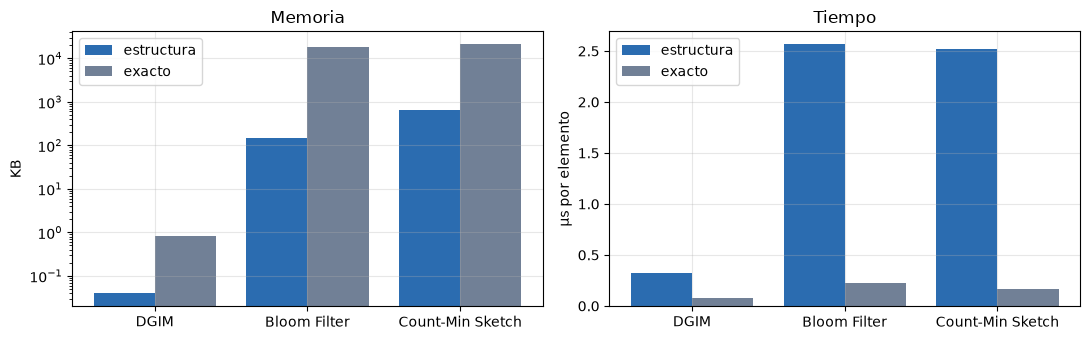

,estructura,memoria_bytes,memoria_exacta_bytes,ahorro_memoria,us_por_elemento,us_por_elemento_exacto,costo_tiempo
0,DGIM,40.38,825.0,20.43,0.32,0.08,4.08
1,Bloom Filter,148414.00,18960499.0,127.75,2.56,0.22,11.57
2,Count-Min Sketch,667800.00,22079231.0,33.06,2.52,0.16,15.36


In [8]:
resumen["ahorro_memoria"] = resumen["memoria_exacta_bytes"] / resumen["memoria_bytes"]
resumen["costo_tiempo"] = resumen["us_por_elemento"] / resumen["us_por_elemento_exacto"]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
x = np.arange(len(resumen))
ax[0].bar(x - 0.2, resumen["memoria_bytes"] / 1024, width=0.4, color="#2b6cb0", label="estructura")
ax[0].bar(x + 0.2, resumen["memoria_exacta_bytes"] / 1024, width=0.4, color="#718096", label="exacto")
ax[0].set_yscale("log"); ax[0].set_ylabel("KB"); ax[0].set_title("Memoria")
ax[1].bar(x - 0.2, resumen["us_por_elemento"], width=0.4, color="#2b6cb0", label="estructura")
ax[1].bar(x + 0.2, resumen["us_por_elemento_exacto"], width=0.4, color="#718096", label="exacto")
ax[1].set_ylabel("µs por elemento"); ax[1].set_title("Tiempo")
for a_ in ax:
    a_.set_xticks(x); a_.set_xticklabels(resumen["estructura"]); a_.legend()
mostrar_fig("memoria_tiempo")

resumen[["estructura", "memoria_bytes", "memoria_exacta_bytes", "ahorro_memoria",
         "us_por_elemento", "us_por_elemento_exacto", "costo_tiempo"]].round(2)

- Ahorro de memoria: DGIM 20x (40 B vs 825 B), Bloom 128x (145 KB vs 18.1 MB), Count-Min 33x (652 KB vs 21.1 MB)

- El ahorro de DGIM es chico en bytes porque la ventana exacta como bits ya es pequeña; crece con `N` (50x en trimestre)

- Bloom ahorra más que Count-Min porque guarda 1 bit por posición en vez de un contador de 32 bits

- En tiempo las 3 son 4-15x más lentas que el exacto: son Python puro contra `set`/`dict`/`deque` implementados en C

- La ventaja es la memoria fija: no crece con numero de pares distintos (Bloom, Count-Min) y crece solo log² con DGIM

### 4. Interpretación

#### a. DGIM - Postor único

In [9]:
s = serie[serie["ventana_llena"]].copy()
s["fecha"] = pd.to_datetime(s["fecha"])
picos = s.nlargest(5, "pct_postor_unico")[["fecha", "exacto", "estimado", "pct_postor_unico"]]
valles = s.nsmallest(5, "pct_postor_unico")[["fecha", "exacto", "estimado", "pct_postor_unico"]]
por_anio = s.groupby(s["fecha"].dt.year)["pct_postor_unico"].agg(["mean", "min", "max"]).round(1)
display(por_anio, picos, valles)

,mean,min,max
fecha,,,
2023,11.9,8.8,19.0
2024,11.3,6.2,21.0
2025,11.4,5.1,17.1


,fecha,exacto,estimado,pct_postor_unico
273,2024-01-22,1387,1447.0,21.015152
274,2024-01-23,1386,1464.0,21.000000
281,2024-01-30,1376,1520.0,20.848485
275,2024-01-24,1374,1470.0,20.818182
272,2024-01-21,1369,1428.0,20.742424


,fecha,exacto,estimado,pct_postor_unico
629,2025-04-21,339,278.0,5.136364
630,2025-04-22,391,331.0,5.924242
517,2024-11-27,409,347.0,6.196970
516,2024-11-26,411,508.0,6.227273
518,2024-11-28,426,382.0,6.454545


- El % de postor único en la ventana promedia 11.9% (2023), 11.3% (2024) y 11.4% (2025)

- El pico se presenta en enero de 2024

- Los valles se presentan en noviembre de 2024 (6.2%) y abril de 2025 (5.1%)

#### b. Bloom Filter - Reincidencia

In [10]:
anual = reincidencia_mes.groupby("anio")[["pct_reincide_exacto", "pct_reincide_bloom"]].mean().round(1)
display(anual, postor_reincidencia)

,pct_reincide_exacto,pct_reincide_bloom
anio,,
2023,19.0,19.0
2024,35.2,35.2
2025,41.2,41.5


,par,llegadas,pct_postor_unico
0,primera vez,123860,11.9
1,reincidente,60369,16.3


- Un tercio de las llegadas repite un par entidad-proveedor; la proporción sube año a año (19.0% → 35.2% → 41.2%)

- Los pares reincidentes tienen más postor único que en su primera aparición (16.3% vs 11.9%)

- Bloom replica la reincidencia exacta por año usando 128x menos memoria

#### c. Count-Min Sketch - Pares más frecuentes

In [11]:
heavy_hitters[["par", "exacto", "estimado", "detectado_en_linea", "pct_postor_unico"]]

,par,exacto,estimado,detectado_en_linea,pct_postor_unico
0,COMISION DE PROMOCION DEL PERU PARA LA EXPORTACION Y EL TURISMO - PROMPERU|M...,155,157,True,100.0
1,GOBIERNO REGIONAL DE PUNO SEDE CENTRAL|GRUPO SANTA FE SOCIEDAD ANONIMA CERRA...,153,154,True,0.0
2,COMISION DE PROMOCION DEL PERU PARA LA EXPORTACION Y EL TURISMO - PROMPERU|G...,128,129,True,100.0
3,COMISION DE PROMOCION DEL PERU PARA LA EXPORTACION Y EL TURISMO - PROMPERU|T...,113,113,True,100.0
4,SEGURO SOCIAL DE SALUD|CARDIO PERFUSION E.I.R.LTDA,73,75,True,30.1
5,SEGURO SOCIAL DE SALUD|DIAGNOSTICA PERUANA S.A.C.,62,67,True,3.2
6,GOBIERNO REGIONAL DE MADRE DE DIOS SEDE CENTRAL|GRUPO SANTA FE SOCIEDAD ANON...,58,59,True,0.0
7,MTC-PROYECTO ESPECIAL DE INFRAESTRUCTURA DE TRANSPORTE NACIONAL (PROVIAS NAC...,57,59,True,100.0
8,SEGURO SOCIAL DE SALUD|CYMED MEDICAL SAC,57,59,True,47.4
9,CENTRO NACIONAL DE ABASTECIMIENTO DE RECURSOS ESTRATEGICOS EN SALUD|MEDIFARM...,57,59,True,1.8


- Los pares más repetidos combinan dos perfiles: proveedores dominantes en mercados competitivos y contrataciones sin competencia por diseño

- Sin competencia: PROMPERÚ con Meta, Google y TikTok (Contratación Internacional de publicidad digital, 100% postor único)

- Sin competencia: PROVIAS Nacional con una persona natural (100%, defensa legal) y algunos proveedores médicos de ESSALUD (CYMED 47.4%, Cardio Perfusion 30.1%)

### 5. Variación de los resultados

Resumen de los hallazgos variando los parametros

#### a. DGIM - Tamaño de la ventana

In [12]:
var_dgim = leer("a_dgim", "variacion")
var_dgim[["ventana", "N", "pct_medio", "pct_desv", "pct_min", "pct_max", "fecha_max_exacto",
          "dias_alerta_exacto", "dias_alerta_dgim", "alertas_acertadas"]].round(1)

/var/folders/sm/j3wvc6514qv165w4d43_hg040000gn/T/ipykernel_52852/3641704277.py:3: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  "dias_alerta_exacto", "dias_alerta_dgim", "alertas_acertadas"]].round(1)


,ventana,N,pct_medio,pct_desv,pct_min,pct_max,fecha_max_exacto,dias_alerta_exacto,dias_alerta_dgim,alertas_acertadas
0,semana,1500,11.6,4.8,1.9,30.6,2024-07-01,145,143,117
1,mes,6600,11.5,3.1,5.1,21.0,2024-01-22,129,136,108
2,trimestre,19800,11.1,1.6,8.3,14.9,2025-03-26,0,39,0


#### b. Bloom Filter - Bits por par y funciones hash

In [13]:
var_bloom = leer("b_bloom", "variacion")
print(f"Exacto: reincidencia {var_bloom['reincidencia_exacta'].iloc[0]:.1f}% | brecha {var_bloom['brecha_pu_exacta'].iloc[0]:+.1f} pp")
display(var_bloom.pivot(index="bits_por_par", columns="k", values="reincidencia").round(1),
        var_bloom.pivot(index="bits_por_par", columns="k", values="brecha_pu").round(1))

Exacto: reincidencia 32.8% | brecha +4.4 pp


k,1,2,3,5,7,10
bits_por_par,,,,,,
2.0,47.1,44.1,44.7,48.8,54.1,61.5
4.0,40.6,36.7,35.8,35.9,37.0,39.7
8.0,36.9,34.0,33.3,33.1,33.0,33.1
9.6,36.1,33.6,33.1,32.9,32.9,32.9
16.0,34.8,33.1,32.9,32.8,32.8,32.8


k,1,2,3,5,7,10
bits_por_par,,,,,,
2.0,2.4,2.7,2.5,2.1,1.5,0.6
4.0,3.2,3.8,4.0,3.8,3.6,3.2
8.0,3.7,4.2,4.3,4.3,4.3,4.3
9.6,3.8,4.2,4.4,4.4,4.4,4.4
16.0,4.0,4.4,4.4,4.4,4.4,4.4


#### c. Count-Min Sketch - Ancho y profundidad

In [14]:
var_cms = leer("c_sketch", "variacion")
print(f"Exacto: {var_cms['hh_reales'].iloc[0]} heavy hitters | % postor único promedio {var_cms['pct_postor_unico_hh_real'].iloc[0]:.1f}%")
var_cms[["w", "d", "conservador", "hh_reportados", "hh_falsos", "top20_coinciden", "pct_postor_unico_hh"]].round(1)

Exacto: 16 heavy hitters | % postor único promedio 31.0%


,w,d,conservador,hh_reportados,hh_falsos,top20_coinciden,pct_postor_unico_hh
0,1024,1,False,123871,123855,1,11.9
1,1024,2,False,123871,123855,6,11.9
2,1024,3,False,123871,123855,7,11.9
3,1024,5,False,123871,123855,15,11.9
4,1024,5,True,123871,123855,6,11.9
5,1024,7,False,123871,123855,14,11.9
6,4096,1,False,41793,41777,1,12.1
7,4096,2,False,14603,14587,10,12.7
8,4096,3,False,5306,5290,16,13.0
9,4096,5,False,846,830,18,14.7


- **DGIM**: la ventana cambia el hallazgo más que el error. El promedio de postor único es estable (~11%), pero el pico va de 30.6% (semana, jul-2024) a 21.0% (mes, ene-2024) y 14.9% (trimestre, mar-2025)

- **DGIM**: la coincidencia de alertas es 81% con semana y 84% con mes; con la ventana semanal hay varios picos cercanos a 30% y DGIM ubica el máximo en mar-2025 (35.4% estimado vs 28.3% real) en vez de jul-2024

- **BF**: con ≤ 4 bits por par la reincidencia se infla (hasta 61.5% vs 32.8%), desde 8 bits el hallazgo es estable

- **CMS**: con w ≤ 4,096 se reportan cientos a miles de falsos heavy hitters; con *conservative update* basta w=4,096

- En **BF** y **CMS** los parámetros hacen que el resultado ya no cambie; en DGIM la ventana es una decisión de análisis

### 6. Síntesis

- **Temporal**: la baja competencia se concentra en enero y en diciembre

- **Reincidencia**: un tercio de las llegadas repite par, y los reincidentes tienen más postor único (16.3% vs 11.9%)

- **Pares frecuentes**: mayormente competitivos; las excepciones son contrataciones sin competencia por diseño

- **Compromiso**: con `r`, `m/n`·`k` y `w`·`d` se intercambia memoria por precisión ; el tiempo depende de `r`, `k` y `d`, no de la memoria

- **Sensibilidad**: con poca memoria, Bloom y Count-Min inflan la reincidencia y diluyen la relación con postor único; En DGIM, el tamaño de la ventana cambia qué picos se ven y cuántas alertas se emiten

### 7. Escritura de resultados

Comparativa en `temp/d_analisis/tablas/` y `temp/d_analisis/web/`

In [15]:
escritos = {"comparativa": guardar_tabla(resumen, "comparativa")}
print(f"Escrito en temp/d_analisis/: {', '.join(escritos)}")

Escrito en temp/d_analisis/: comparativa


#### a. Verificación

In [16]:
for nombre, n in escritos.items():
    leido = spark.read.parquet(str(tab_dir / nombre)).count()
    assert leido == n, f"{nombre}: esperaba {n}, leí {leido}"
    assert (web_dir / f"{nombre}.json").exists(), f"falta web/{nombre}.json"

figs = sorted(p.stem for p in fig_dir.glob("*.png"))
print(f"OK: {len(escritos)} tablas (parquet + json) | {len(figs)} figuras: {', '.join(figs)}")

OK: 1 tablas (parquet + json) | 1 figuras: memoria_tiempo


---
### 8. Cerrar sesión

In [17]:
spark.stop()